# HW: Imbalanced data, Evaluation metrics, Cross validation

繳交網址：https://forms.gle/gjfsbxxtqrSKbuVV7 <br>
繳交期限：4/11 23:55 <br>
重複繳交以最新的做計算

HW-1

作業說明：請自行定義一個函式 def split_data(): 切分imbalanced data<br>
情境：一份DF有N個類別，放入split_data()之後自動切出x_train, y_train, x_test, y_test，<br>
其中x_train, y_train, x_test, y_test內比例與DF中各類別比例需相同。<br>
函式input：自行定義<br>
函式output：x_train, y_train, x_test, y_test<br>
不可使用from sklearn.model_selection import train_test_split套件，其他皆可使用<br>
<br>
配分方式(總分60)：<br>
1. 按label比例分(得60分)，未按label比例(得40分)

Hint: 可參考Split data to train and test那段<br>
1. 整理不平衡資料時，需要將不同類別的資料單獨拉出來，以方便後續切分資料所使用
2. 創建temp_df存取不同類別的資料，創建out_df存取最終return的資料
3. out_df = pd.concat([out_df, temp_df], axis=0)
3. 檢查是否與raw data的分配比例一樣

In [23]:
import seaborn as sns
from pandas import Series
from sklearn.preprocessing import LabelEncoder
import random

In [24]:
import pandas as pd
input_df = pd.read_csv('HW1_data.csv')

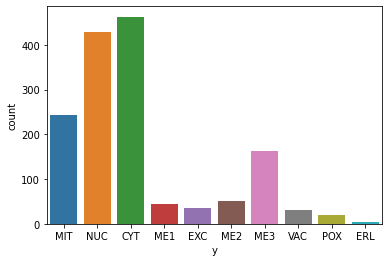

In [25]:
# 查看y
ax = sns.countplot(x = "y", data = input_df)

In [26]:
# 計算 Label 比例
print('MIT class:', sum(input_df['y']=='MIT'))
print('NUC class:', sum(input_df['y']=='NUC'))
print('CYT class:', sum(input_df['y']=='CYT'))
print('ME1 class:', sum(input_df['y']=='ME1'))
print('EXC class:', sum(input_df['y']=='EXC'))
print('ME2 class:', sum(input_df['y']=='ME2'))
print('ME3 class:', sum(input_df['y']=='ME3'))
print('VAC class:', sum(input_df['y']=='VAC'))
print('POX class:', sum(input_df['y']=='POX'))
print('ERL class:', sum(input_df['y']=='ERL'))

print('MIT class ratio:', sum(input_df['y']=='MIT')/len(input_df))
print('NUC class ratio:', sum(input_df['y']=='NUC')/len(input_df))
print('CYT class ratio:', sum(input_df['y']=='CYT')/len(input_df))
print('ME1 class ratio:', sum(input_df['y']=='ME1')/len(input_df))
print('EXC class ratio:', sum(input_df['y']=='EXC')/len(input_df))
print('ME2 class ratio:', sum(input_df['y']=='ME2')/len(input_df))
print('ME3 class ratio:', sum(input_df['y']=='ME3')/len(input_df))
print('VAC class ratio:', sum(input_df['y']=='VAC')/len(input_df))
print('POX class ratio:', sum(input_df['y']=='POX')/len(input_df))
print('ERL class ratio:', sum(input_df['y']=='ERL')/len(input_df))

MIT class: 244
NUC class: 429
CYT class: 463
ME1 class: 44
EXC class: 35
ME2 class: 51
ME3 class: 163
VAC class: 30
POX class: 20
ERL class: 5
MIT class ratio: 0.16442048517520216
NUC class ratio: 0.2890835579514825
CYT class ratio: 0.3119946091644205
ME1 class ratio: 0.029649595687331536
EXC class ratio: 0.02358490566037736
ME2 class ratio: 0.03436657681940701
ME3 class ratio: 0.10983827493261455
VAC class ratio: 0.02021563342318059
POX class ratio: 0.013477088948787063
ERL class ratio: 0.0033692722371967657


In [27]:
def split_data(input_df, test_size):
    
    train_ratio = test_size
    num_data = len(input_df)
    train_len = int(num_data * train_ratio)
    test_len = num_data - train_len
    
    init_list = list(range(num_data))
    random.shuffle(init_list)
    
    train_df =  pd.DataFrame()
    test_df = pd.DataFrame()
    
    count = 0
    for i in init_list:
        if count < train_len:
            train_df = pd.concat([train_df,pd.DataFrame(input_df.iloc[i]).T], axis=0).reset_index(drop=True)
            count+=1            
        else:
            test_df = pd.concat([test_df,pd.DataFrame(input_df.iloc[i]).T], axis=0).reset_index(drop=True)
            count+=1
            
    x_train = train_df.drop(['y'],axis=1)
    y_train = train_df['y']
    x_test = test_df.drop(['y'],axis=1)
    y_test = test_df['y']
    
    le = LabelEncoder()
    le.fit(['MIT','NUC','CYT','ME1','EXC','ME2','ME3','VAC','POX','ERL'])
    y_train = le.transform(y_train)
    y_test = le.transform(y_test)
    
    return x_train, y_train, x_test, y_test

In [28]:
split_data(input_df,0.8)

(     Sequence_Name   mcg   gvh   alm   mit  erl pox   vac   nuc
 0       VATC_YEAST  0.64  0.61  0.56  0.15  0.5   0  0.54  0.22
 1       UCR1_YEAST  0.58  0.58  0.58  0.49  0.5   0  0.49  0.26
 2       DLD1_YEAST  0.47  0.65  0.54  0.62  0.5   0  0.53  0.36
 3       RPD3_YEAST  0.37   0.3  0.51  0.15  0.5   0  0.58  0.26
 4       PRC5_YEAST  0.28  0.51  0.55  0.19  0.5   0  0.57  0.22
 ...            ...   ...   ...   ...   ...  ...  ..   ...   ...
 1182    VPH1_YEAST  0.57  0.54  0.32  0.15  0.5   0  0.52  0.25
 1183    HXKG_YEAST  0.48  0.39  0.49  0.18  0.5   0  0.51  0.22
 1184    DMC1_YEAST  0.43  0.39  0.54  0.14  0.5   0  0.47  0.22
 1185    CC42_YEAST  0.59  0.48   0.5  0.14  0.5   0  0.45  0.25
 1186    CTK1_YEAST  0.31  0.46  0.54  0.52  0.5   0   0.5  0.34
 
 [1187 rows x 9 columns],
 array([9, 6, 6, ..., 7, 0, 7]),
     Sequence_Name   mcg   gvh   alm   mit  erl pox   vac   nuc
 0      SRB4_YEAST  0.49   0.6  0.42  0.18  0.5   0  0.58  0.28
 1      RFA2_YEAST  0.46  0.41 

HW-2

作業說明(總分40)： <br>
以def定義N類別的recall function (得20分)<br>
函式input：y_true, y_pred<br>
函式output：recall<br>
以def定義N類別的precision function (得20分)<br>
函式input：y_true, y_pred<br>
函式output：recall<br>
套件皆可使用

reference<br>
https://medium.com/data-science-in-your-pocket/calculating-precision-recall-for-multi-class-classification-9055931ee229

Hint: 可參考Evaluation metrics (HW-2)那段<br>
可以用confusing matrix幫忙計算<br>
可利用from sklearn.metrics import recall_score, precision_score<br>

recall:    array([0.6847, 0.6   , 0.7714, 0.4545, 0.7255, 0.8405, 0.9098, 0.9301,   0.85  , 0.9   ])<br>
precision: array([0.883 , 1.    , 0.7105, 0.6061, 0.6066, 0.7249, 0.8506, 0.8244,   0.68  , 0.871 ])

In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv('HW2_data.csv')
y_pred = df['y_pred']
y_true = df['y_true']
le = LabelEncoder()
le.fit(y_true)
y_true = le.transform(y_true)
y_pred = le.transform(y_pred)

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
cm = confusion_matrix(df["y_true"], df["y_pred"])
recall = recall_score(df["y_true"], df["y_pred"], average=None)
precision = precision_score(df["y_true"], df["y_pred"], average=None)

In [31]:
def multi_recall(y_true, y_pred):
  recall = recall_score(y_true, y_pred, average=None)
  return recall

multi_recall(df["y_true"], df["y_pred"])

array([0.68466523, 0.6       , 0.77142857, 0.45454545, 0.7254902 ,
       0.8404908 , 0.90983607, 0.93006993, 0.85      , 0.9       ])

In [32]:
def multi_precision(y_true, y_pred):
  precision = precision_score(y_true, y_pred, average=None)
  return precision

multi_precision(df["y_true"], df["y_pred"])

array([0.88300836, 1.        , 0.71052632, 0.60606061, 0.60655738,
       0.72486772, 0.85057471, 0.82438017, 0.68      , 0.87096774])